# batlab quickstart

Ten-minute tour: load a real dataset in batlab's standardized schema, engineer features, train
a leave-cell-out-validated SOH/RUL model, and predict — all against the small NASA PCoE CSVs
already committed in this repo (`data/raw/`), so nothing here needs a network connection.

In [1]:
import matplotlib.pyplot as plt
import batlab
from batlab.datasets import load_nasa_cells, validate_schema
from batlab.features import build_features, get_model_matrix
from batlab.models import train_models, predict
from batlab.validation import run_lco

print(f"batlab {batlab.__version__}")

batlab 0.1.1


## 1. Load a dataset

Every batlab loader returns `{cell_id: DataFrame}` in one standardized schema — see `batlab.datasets.schema`.

In [2]:
cells = load_nasa_cells()
print(f"Loaded {len(cells)} cells: {sorted(cells)}")

df = cells["B0005"]
validate_schema(df, kind="cycle")  # raises SchemaError with a specific message on any violation
df.head()

  [cache] B0005 already parsed (168 cycles)
  [cache] B0006 already parsed (168 cycles)
  [cache] B0007 already parsed (168 cycles)
  [cache] B0018 already parsed (132 cycles)
Loaded 4 cells: ['B0005', 'B0006', 'B0007', 'B0018']


,cycle_number,capacity_ah,resistance_ohm,temperature_c,soh_pct
0,1,1.85649,0.04467,32.57,100.000000
1,2,1.84633,0.04669,32.73,99.452731
2,3,1.83535,0.04484,32.64,98.861292
3,4,1.83526,0.04619,32.51,98.856444
4,5,1.83465,0.04510,32.38,98.823586


In [3]:
print("df.attrs:", df.attrs)
print(f"{len(df)} cycles, SOH {df['soh_pct'].iloc[0]:.1f}% -> {df['soh_pct'].iloc[-1]:.1f}%")

df.attrs: {'cell_id': 'B0005', 'source': 'nasa', 'chemistry': 'LiCoO2', 'citation': 'nasa', 'license': 'Public domain / US government work'}
168 cycles, SOH 100.0% -> 71.4%


## 2. Feature engineering

`build_features()` adds fade-rate, dQ/dV, resistance, and stress-index features — see its docstring for the literature each one implements.

In [4]:
featured = {cid: build_features(cell_df) for cid, cell_df in cells.items()}
X, y_soh, y_rul = get_model_matrix(featured["B0005"])
print(f"{X.shape[0]} usable rows, {X.shape[1]} features")
list(X.columns)

166 usable rows, 14 features


['cycle_number',
 'fade_rate_10cy',
 'fade_rate_30cy',
 'fade_rate_50cy',
 'fade_acceleration',
 'soh_velocity_50cy',
 'resistance_ohm',
 'resistance_normalized',
 'resistance_trend_30cy',
 'temp_rolling_30cy',
 'dqdv_sim_peak_value',
 'dqdv_sim_peak_soc',
 'dqdv_sim_area',
 'dqdv_sim_fwhm']

## 3. How reliable is this, honestly?

Leave-cell-out (LCO) cross-validation — train on 3 cells, test on the 4th, held out entirely —
is the honest way to ask "does this generalize to a cell the model has never seen?" See
`notebooks/02_data_leakage.ipynb` for why a naive row-level split lies about this number.

In [5]:
lco = run_lco(cells)
print(f"LCO SOH R2:  {lco['soh_r2']:.3f}   MAE: {lco['soh_mae']:.2f}%")
print(f"LCO RUL R2:  {lco['rul_r2']:.3f}   MAE: {lco['rul_mae']:.1f} cycles")
print(f"RUL reliable (R2 >= 0.30 floor): {lco['rul_reliable']}")
for cell_id, m in lco["per_cell"].items():
    print(f"  {cell_id}: fold RUL R2 = {m['rul_r2']:.3f}")

LCO SOH R2:  0.806   MAE: 3.69%
LCO RUL R2:  0.797   MAE: 7.4 cycles
RUL reliable (R2 >= 0.30 floor): True
  B0005: fold RUL R2 = 0.910
  B0006: fold RUL R2 = 0.464
  B0007: fold RUL R2 = 0.890
  B0018: fold RUL R2 = 0.924


## 4. Train on all cells and predict

For an actual prediction (not just cross-validated evaluation), train on the full population.

In [6]:
X_all = __import__("pandas").concat([get_model_matrix(f)[0] for f in featured.values()])
y_soh_all = __import__("pandas").concat([get_model_matrix(f)[1] for f in featured.values()])
y_rul_all = __import__("pandas").concat([get_model_matrix(f)[2] for f in featured.values()])

bundle = train_models(X_all, y_soh_all, y_rul_all)
print(f"Held-out test R2 -- SOH: {bundle['metrics']['soh_r2']:.3f}, RUL: {bundle['metrics']['rul_r2']:.3f}")

Held-out test R2 -- SOH: 0.697, RUL: 0.928


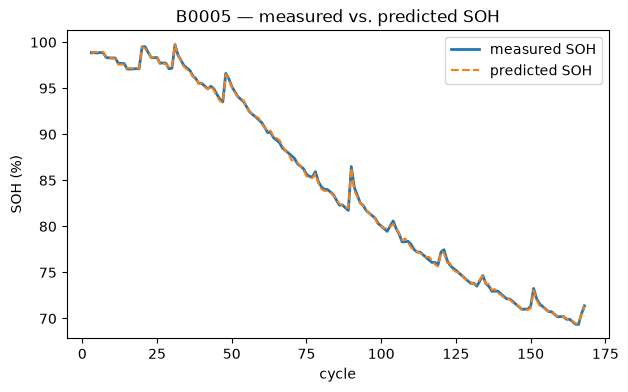

In [7]:
preds = predict(bundle, X)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X["cycle_number"], y_soh, label="measured SOH", lw=2)
ax.plot(X["cycle_number"], preds["soh_pred"], label="predicted SOH", lw=1.5, ls="--")
ax.set_xlabel("cycle"); ax.set_ylabel("SOH (%)"); ax.set_title("B0005 — measured vs. predicted SOH")
ax.legend(); plt.show()

## 5. Cite this

In [8]:
print(batlab.cite())
print()
print(batlab.cite(dataset="nasa"))

@software{batlab,
  title  = {batlab: a citable, honest research library for battery degradation analysis},
  author = {Hosseini, Ali},
  year   = {2026},
  url    = {https://github.com/seyedali1996lb-svg/battery-intelligence-platform},
  doi    = {10.5281/zenodo.21346275},
  note   = {Standardized dataset loaders, leave-cell-out-validated SOH/RUL models, and reproducible benchmark manifests.}
}

@techreport{saha2007nasa,
  title       = {Battery Data Set},
  author      = {Saha, Bhaskar and Goebel, Kai},
  institution = {NASA Ames Prognostics Center of Excellence (PCoE)},
  year        = {2007},
  url         = {https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/}
}
% License: Public domain / US government work.
